In [2]:
import cv2 as cv
import os
import numpy as np
import matplotlib.pyplot as plt
from mtcnn.mtcnn import MTCNN
from keras_facenet import FaceNet
import tensorflow as tf
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Tensorflow warning কমানোর জন্য

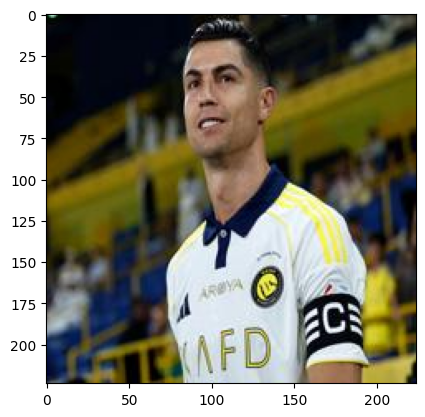

In [8]:
# একটি সিঙ্গেল ইমেজ লোড করা
img = cv.imread('../img_dataset/test/ronaldo/19.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)  # OpenCV BGR থেকে RGB তে কনভার্ট

plt.imshow(img)
plt.show()

In [9]:
detector = MTCNN()
results = detector.detect_faces(img)
print(results)

[{'box': [82, 18, 46, 65], 'confidence': np.float64(0.9996812343597412), 'keypoints': {'nose': [np.int64(95), np.int64(51)], 'mouth_right': [np.int64(108), np.int64(65)], 'right_eye': [np.int64(109), np.int64(39)], 'left_eye': [np.int64(90), np.int64(41)], 'mouth_left': [np.int64(92), np.int64(67)]}}]


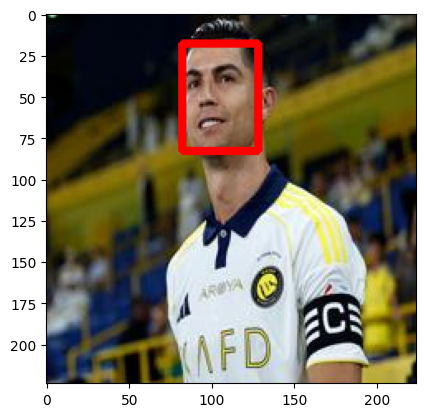

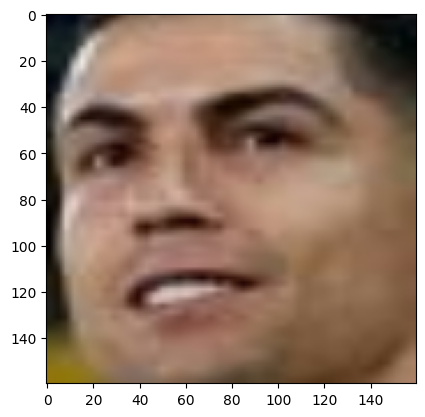

In [10]:
# প্রথম detected face এর box
x, y, w, h = results[0]['box']

# মুখের চারপাশে rectangle
img_boxed = cv.rectangle(img.copy(), (x, y), (x+w, y+h), (255,0,0), 3)
plt.imshow(img_boxed)
plt.show()

# মুখ crop করা এবং 160x160 resize করা
my_face = img[y:y+h, x:x+w]
my_face = cv.resize(my_face, (160,160))
plt.imshow(my_face)
plt.show()

In [11]:
class FACELOADING:
    def __init__(self, directory):
        self.directory = directory
        self.target_size = (160,160)
        self.X = []  # ইমেজ data
        self.Y = []  # লেবেল
        self.detector = MTCNN()  # মুখ শনাক্তকরণ
    
    # একটিমাত্র ইমেজ থেকে মুখ বের করা
    def extract_face(self, filename):
        img = cv.imread(filename)
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        x, y, w, h = self.detector.detect_faces(img)[0]['box']
        x, y = abs(x), abs(y)  # negative index fix
        face = img[y:y+h, x:x+w]
        face_arr = cv.resize(face, self.target_size)
        return face_arr
    
    # একটি ক্লাসের সব ছবি লোড করা
    def load_faces(self, dir):
        FACES = []
        for im_name in os.listdir(dir):
            try:
                path = dir + im_name
                single_face = self.extract_face(path)
                FACES.append(single_face)
            except Exception as e:
                pass
        return FACES

    # সব ক্লাসের ছবি লোড করা
    def load_classes(self):
        for sub_dir in os.listdir(self.directory):
            path = os.path.join(self.directory, sub_dir) + '/'
            FACES = self.load_faces(path)
            labels = [sub_dir for _ in range(len(FACES))]
            print(f"Loaded {len(labels)} images for class '{sub_dir}'")
            self.X.extend(FACES)
            self.Y.extend(labels)
        return np.asarray(self.X), np.asarray(self.Y)
    
    # লোড করা ছবিগুলো plot করা
    def plot_images(self):
        plt.figure(figsize=(18,16))
        for num, image in enumerate(self.X):
            ncols = 3
            nrows = len(self.Y)//ncols + 1
            plt.subplot(nrows, ncols, num+1)
            plt.imshow(image)
            plt.axis('off')

Loaded 9 images for class 'fernandes'


2025-11-04 08:41:00.029352: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: INVALID_ARGUMENT: Incompatible shapes: [0,48,48,3] vs. [1,1,1,32]


Loaded 9 images for class 'sinner'
Loaded 10 images for class 'shelton'
Loaded 13 images for class 'ronaldo'
Loaded 10 images for class 'smith'
Loaded 10 images for class 'cummins'


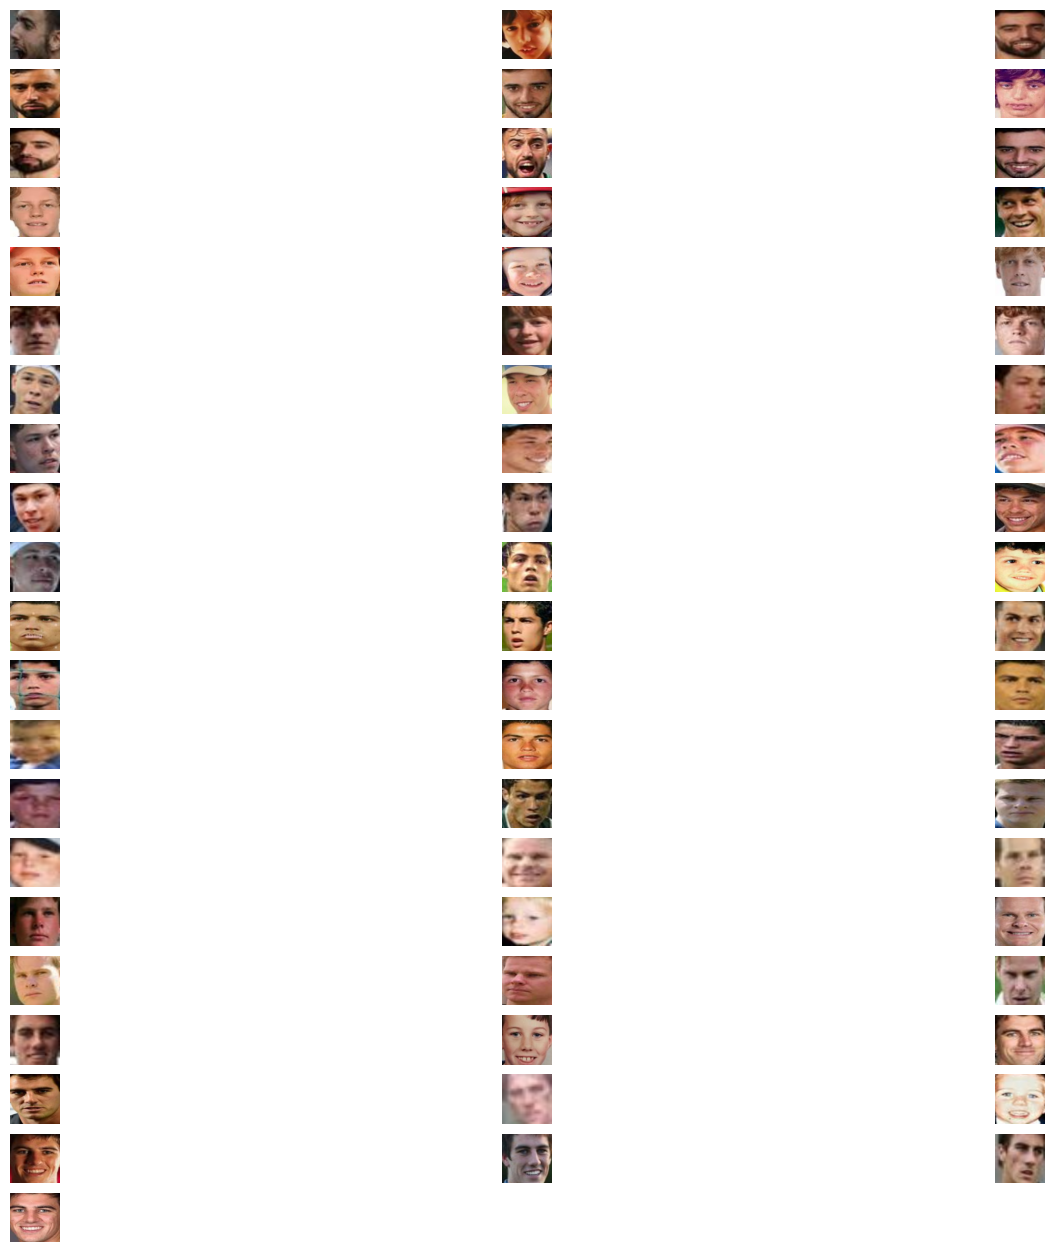

In [13]:
faceloading = FACELOADING('../img_dataset/train/')
X, Y = faceloading.load_classes()
faceloading.plot_images()
plt.show()

In [14]:
embedder = FaceNet()

def get_embedding(face_img):
    face_img = face_img.astype('float32')
    face_img = np.expand_dims(face_img, axis=0)  # (1,160,160,3)
    yhat = embedder.embeddings(face_img)
    return yhat[0]  # 512D embedding

In [15]:
EMBEDDED_X = np.array([get_embedding(img) for img in X])
np.savez_compressed('faces_embeddings_done.npz', EMBEDDED_X, Y)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━

In [16]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
encoder.fit(Y)
Y_enc = encoder.transform(Y)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(EMBEDDED_X, Y_enc, shuffle=True, random_state=17)

In [18]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

model = SVC(kernel='linear', probability=True)
model.fit(X_train, Y_train)

# Accuracy দেখানো
train_acc = accuracy_score(Y_train, model.predict(X_train))
test_acc = accuracy_score(Y_test, model.predict(X_test))
print(f"Train Accuracy: {train_acc}")
print(f"Test Accuracy: {test_acc}")

Train Accuracy: 1.0
Test Accuracy: 0.8125


In [24]:
t_im = cv.imread('../img_dataset/test/smith/15.jpg')
t_im = cv.cvtColor(t_im, cv.COLOR_BGR2RGB)
x, y, w, h = detector.detect_faces(t_im)[0]['box']
t_im = t_im[y:y+h, x:x+w]
t_im = cv.resize(t_im, (160,160))
test_im = get_embedding(t_im).reshape(1,-1)

ypreds = model.predict(test_im)
pred_name = encoder.inverse_transform(ypreds)
print(f"Predicted Person: {pred_name[0]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted Person: smith
